# B2.6 Problems
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.1 — Unmarked Cruiser vs. Speeding SUV

An SUV blasts past an unmarked police cruiser at a steady $v_s = 36.0~\text{m/s}$.  
At that instant ($t=0$), the cruiser starts from rest and accelerates uniformly at $a = 3.20~\text{m/s}^2$ to catch up.

1) **How long** does it take the cruiser to catch the SUV?

2) **Confirm with a plot** showing both $x(t)$ curves on the same axes and clearly marking the intersection.


### Analytic Derivation

We model both vehicles from the same starting point:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

**Numeric substitution:**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

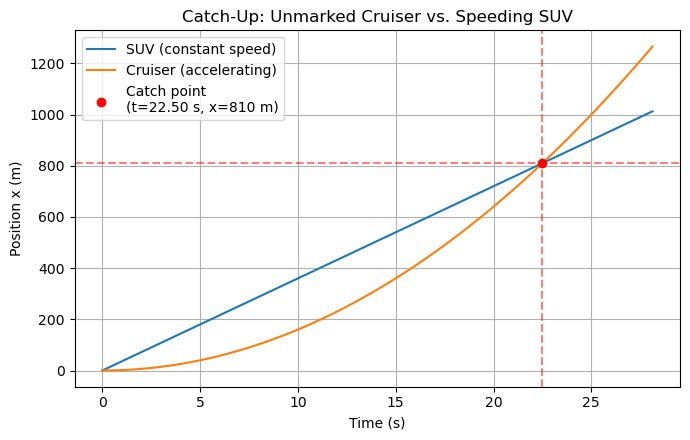

In [47]:
# reset -f

from IPython.display import display, Markdown, Math
import numpy as np
import matplotlib.pyplot as plt

# --- Given values ---
v_s = 36.0     # m/s
a   = 3.20     # m/s^2

# --- Analytic derivation ---
display(Markdown("### Analytic Derivation"))
display(Markdown("We model both vehicles from the same starting point:"))
display(Math(r"x = 0 \text{ at } t = 0"))
display(Math(r"x_{\mathrm{SUV}}(t) = v_s\,t"))
display(Math(r"x_{\mathrm{cruiser}}(t) = \tfrac{1}{2}\,a\,t^2"))

display(Markdown("Catch-up occurs when the positions are equal:"))
display(Math(r"x_{\mathrm{SUV}}(t) = x_{\mathrm{cruiser}}(t) \;\Rightarrow\; v_s\,t = \tfrac{1}{2}\,a\,t^2"))

display(Markdown("Ignoring the trivial solution and solving for time:"))
display(Math(r"t = \frac{2\,v_s}{a}"))

# --- Numerical evaluation ---
t_catch = (2 * v_s) / a
x_catch = v_s * t_catch
v_cruiser = a * t_catch

display(Markdown("**Numeric substitution:**"))

# Instead of f-strings with backslashes, build plain strings:
eq_t = r"t = \frac{2 \cdot %.1f}{%.2f} = %.2f~\text{s}" % (v_s, a, t_catch)
eq_x = r"x = v_s t = (%.1f)(%.2f) = %.0f~\text{m}" % (v_s, t_catch, x_catch)
eq_v = r"v_{\mathrm{cruiser}} = a t = (%.2f)(%.2f) = %.1f~\text{m/s}" % (a, t_catch, v_cruiser)

display(Math(eq_t))
display(Math(eq_x))
display(Math(eq_v))

# --- Plot confirmation ---
t = np.linspace(0, t_catch * 1.25, 300)
x_suv = v_s * t
x_cru = 0.5 * a * t**2

plt.figure(figsize=(7,4.5))
plt.plot(t, x_suv, label="SUV (constant speed)")
plt.plot(t, x_cru, label="Cruiser (accelerating)")
plt.scatter([t_catch], [x_catch], color="red", zorder=5,
            label=f"Catch point\n(t={t_catch:.2f} s, x={x_catch:.0f} m)")
plt.axvline(t_catch, color="red", linestyle="--", alpha=0.5)
plt.axhline(x_catch, color="red", linestyle="--", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Position x (m)")
plt.title("Catch-Up: Unmarked Cruiser vs. Speeding SUV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.2 — The Airliner Takeoff Challenge

Two passenger jets are on parallel runways, preparing for takeoff.  
Both begin rolling at the same time when they are **2.0 km** from the end of the runway.

**Jet A** (the pilot in training) starts with an initial speed of  
$v_0 = 60.0~\text{m/s}$ and increases thrust to achieve a **constant acceleration** of  
$a = 1.20~\text{m/s}^2$ for **15.0 s**, after which it maintains that speed until leaving the runway.

**Jet B** (an experienced pilot) maintains a constant speed of  
$75.0~\text{m/s}$ for the entire distance.

---

### 1. Final velocity at the end of Jet A’s acceleration

Find the **final velocity** at the end of the 15.0 s acceleration phase.

---

### 2. Time saved by accelerating

Determine how much **time Jet A saves** by accelerating for 15.0 s and then continuing at $v_f$ compared to moving at $v_0$ the whole way.

---

### 3. The other pilot’s performance

Jet B starts simultaneously from the same position but never accelerates,  
traveling at $v_B = 75.0~\text{m/s}$ the entire 2000 m.  
When Jet A reaches the runway end, by how many **seconds** and **meters** is Jet B behind (or ahead)?

---

### 4. Plot your results

Plot the following graphs to illustrate your solution:

- **Velocity vs Time:** show Jet A’s acceleration phase, cruise phase, and Jet B’s constant velocity line.  
- **Position vs Time:** show how both jets progress toward the 2000 m mark.


(1) Jet A final velocity = 78.00 m/s
(2) Jet A time saved vs no acceleration = 5.96 s
(3) Jet A finishes -0.71 s earlier and 0.00 m ahead of Jet B.


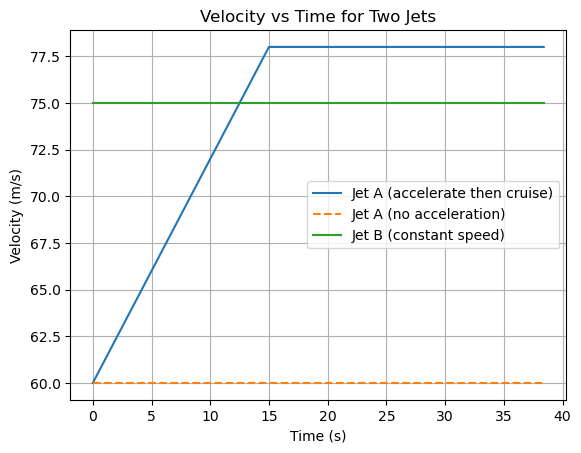

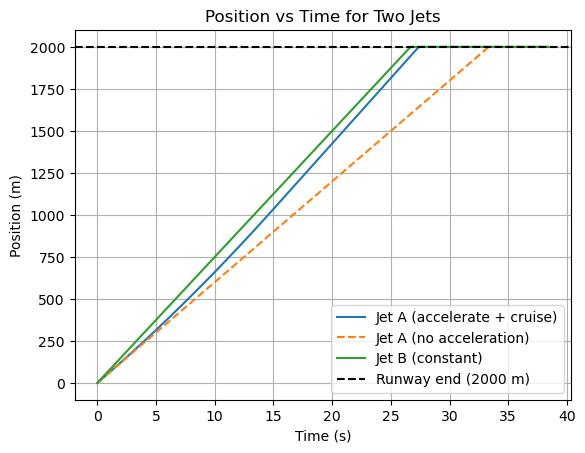

In [20]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# --- Given data ---
v0 = 60.0         # m/s
a = 1.20          # m/s^2
t_accel = 15.0    # s
distance_total = 2000.0  # m
vB = 75.0         # m/s (Jet B constant)
# Both start from same point, so no lead distance.

# --- (1) Final velocity after acceleration ---
v_f = v0 + a * t_accel
print(f"(1) Jet A final velocity = {v_f:.2f} m/s")

# --- (2) Total time for Jet A to cover 2000 m ---
# Distance covered during acceleration:
d_accel = v0 * t_accel + 0.5 * a * t_accel**2

if d_accel >= distance_total:
    # Jet A reaches the end before acceleration finishes
    T_A = (-v0 + np.sqrt(v0**2 + 2*a*distance_total)) / a
else:
    remaining = distance_total - d_accel
    t_cruise = remaining / v_f
    T_A = t_accel + t_cruise

# Time with no acceleration (constant v0)
T_no_accel = distance_total / v0
time_saved = T_no_accel - T_A
print(f"(2) Jet A time saved vs no acceleration = {time_saved:.2f} s")

# --- (3) Jet B comparison ---
T_B = distance_total / vB
time_gap = T_B - T_A
# Distance Jet B has traveled when Jet A finishes
dB_at_finish = min(vB * T_A, distance_total)
distance_gap = distance_total - dB_at_finish
print(f"(3) Jet A finishes {time_gap:.2f} s earlier and {distance_gap:.2f} m ahead of Jet B.")

# --- (4) Build arrays for plotting ---
dt = 0.1
t_end = max(T_A, T_B, T_no_accel) + 5
t = np.arange(0, t_end + dt, dt)

# Jet A velocity (accelerate then cruise)
vA = np.where(t <= t_accel, v0 + a*t, v_f)

# Integrate with trapezoidal rule for Jet A’s position
xA = np.array([np.trapezoid(vA[:i+1], t[:i+1]) for i in range(len(t))])
xA = np.minimum(xA, distance_total)

# Jet A (no-acceleration baseline)
xA_base = np.minimum(v0 * t, distance_total)

# Jet B (constant)
xB = np.minimum(vB * t, distance_total)

# --- Plots ---
plt.figure()
plt.plot(t, vA, label="Jet A (accelerate then cruise)")
plt.plot(t, np.full_like(t, v0), '--', label="Jet A (no acceleration)")
plt.plot(t, np.full_like(t, vB), label="Jet B (constant speed)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs Time for Two Jets")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, xA, label="Jet A (accelerate + cruise)")
plt.plot(t, xA_base, '--', label="Jet A (no acceleration)")
plt.plot(t, xB, label="Jet B (constant)")
plt.axhline(distance_total, color='k', linestyle='--', label="Runway end (2000 m)")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs Time for Two Jets")
plt.grid(True)
plt.legend()
plt.show()


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.3 — Rocket-Sled Acceleration Test

During a rocket-sled test at a desert proving ground, engineers record the sled’s position and velocity over time.  
All measurements are significant to **two significant figures**.

### 1. Using the position–time graph  
Estimate the sled’s **velocity at $t = 12\ \text{s}$** by drawing a tangent to the curve or by using nearby data points.  
Does your estimated velocity agree with the corresponding value on the velocity–time graph?

### 2. Using the velocity–time graph  
Determine whether the **acceleration is constant**, and if so, estimate its value.  
Assume it is constant and express your result in $\text{m/s}^2$.

### 3. Comparing displacement  
From the **velocity–time graph**, estimate the sled’s total **displacement** between $t=0$ and $t=15\ \text{s}$ by finding the area under the curve.  
Compare this with the total displacement read directly from the **position–time graph**.  
Do the two methods give similar results within the precision of the graphs?


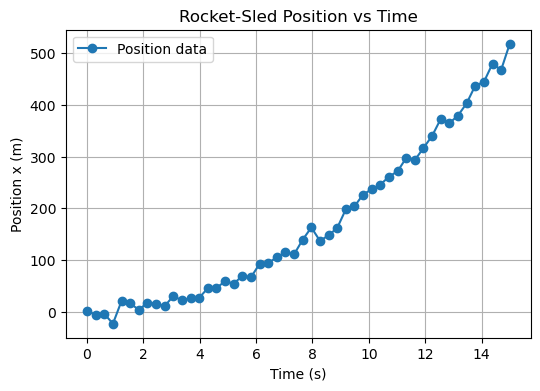

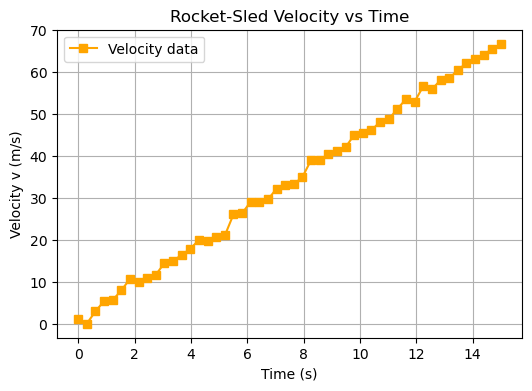

In [25]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Time array
t = np.linspace(0, 15, 50)

# Rocket-sled parameters
a = 4.5   # m/s^2 constant acceleration
v = a * t
x = 0.5 * a * t**2

# Add slight noise for realism (students can ignore this detail)
rng = np.random.default_rng(2)
x_noisy = x + rng.normal(0, 10, size=t.size)     # ±10 m variation
v_noisy = v + rng.normal(0, 1.0, size=t.size)    # ±1 m/s variation

# Position–time plot
plt.figure(figsize=(6,4))
plt.plot(t, x_noisy, 'o-', label='Position data')
plt.xlabel("Time (s)")
plt.ylabel("Position x (m)")
plt.title("Rocket-Sled Position vs Time")
plt.grid(True)
plt.legend()
plt.show()

# Velocity–time plot
plt.figure(figsize=(6,4))
plt.plot(t, v_noisy, 's-', color='orange', label='Velocity data')
plt.xlabel("Time (s)")
plt.ylabel("Velocity v (m/s)")
plt.title("Rocket-Sled Velocity vs Time")
plt.grid(True)
plt.legend()
plt.show()


In [26]:
# sample solution
%reset -f

import numpy as np

# Use same parameters
a_true = 4.5
t = np.linspace(0, 15, 50)
v = a_true * t
x = 0.5 * a_true * t**2

# 1) Estimate velocity at t = 12 s from position–time slope
# Use central difference near 12 s
t_idx = np.argmin(np.abs(t - 12))
dxdt = (x[t_idx+1] - x[t_idx-1]) / (t[t_idx+1] - t[t_idx-1])
v_estimated_from_x = dxdt

# Compare with true v at 12 s
v_from_graph = v[t_idx]

# 2) Estimate acceleration from v–t
dvdt = (v[-1] - v[0]) / (t[-1] - t[0])

# 3) Compare displacements
displacement_from_v = np.trapezoid(v, t)   # area under v–t
displacement_from_x = x[-1] - x[0]

print(f"1) Velocity at t=12 s from x–t ≈ {v_estimated_from_x:.2f} m/s")
print(f"   Velocity from v–t graph ≈ {v_from_graph:.2f} m/s")
print(f"   → They agree within ~{abs(v_from_graph - v_estimated_from_x):.2f} m/s difference.\n")

print(f"2) Acceleration from v–t ≈ {dvdt:.2f} m/s² (constant)\n")

print(f"3) Displacement from v–t area = {displacement_from_v:.1f} m")
print(f"   Displacement from x–t = {displacement_from_x:.1f} m")
print(f"   → Difference = {abs(displacement_from_v - displacement_from_x):.1f} m (~{100*abs(displacement_from_v - displacement_from_x)/displacement_from_x:.1f}% difference)")


1) Velocity at t=12 s from x–t ≈ 53.72 m/s
   Velocity from v–t graph ≈ 53.72 m/s
   → They agree within ~0.00 m/s difference.

2) Acceleration from v–t ≈ 4.50 m/s² (constant)

3) Displacement from v–t area = 506.2 m
   Displacement from x–t = 506.2 m
   → Difference = 0.0 m (~0.0% difference)


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.4 — World-Class Sprinter

A graph of **velocity vs. time** for a world-class 100-m sprinter is shown.  
Assume the curve is smooth and that all measurements are significant to **two significant figures**.

---

### 1. Average velocity for the first 4 s
Using the **position–time** information implied by the graph, estimate the sprinter’s **average velocity** for the first $4.0~\text{s}$:

$$
\bar{v}_{0 \to 4} = \frac{\Delta x}{\Delta t} 
$$

---

### 2. Instantaneous velocity at $t = 5~\text{s}$
From the **velocity–time** graph, estimate the **instantaneous velocity** at $t = 5.0~\text{s}$, i.e. read off $v(5.0~\text{s})$.

---

### 3. Average acceleration between 0 and 4 s
From the **velocity–time** graph, find the **average acceleration** between $t = 0$ and $t = 4.0~\text{s}$:

$$
\bar{a}_{0 \to 4} = \frac{\Delta v}{\Delta t} 
$$

---

### 4. Race time
Determine the **time to complete 100 m**.  
Use the **area under the $v$–$t$ curve** (i.e. the integral of $v(t)$) to find when the cumulative distance first reaches $100~\text{m}$:

$$
x(t) = \int_0^t v(\tau)\,d\tau
$$


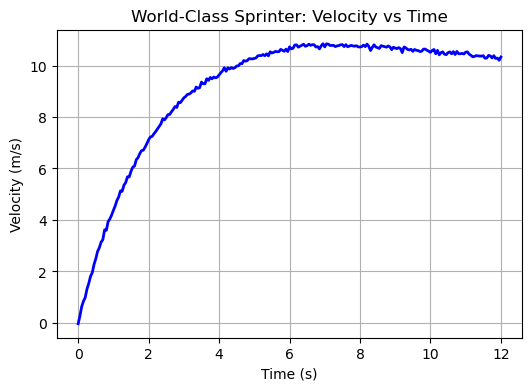

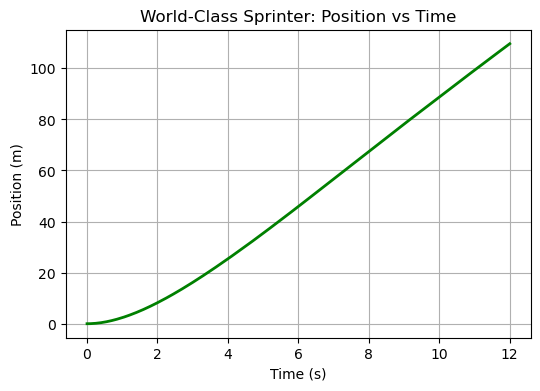

In [27]:
# Python script to create the two plots 
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Time array
dt = 0.05
t = np.arange(0, 12 + dt, dt)

# Simple velocity model for an elite sprinter
# Quick acceleration to near top speed, slight fade at the end
v_max = 11.2        # m/s
tau   = 2.0         # s  (rise time)
t_peak= 6.5         # s  (start of fade)
kfade = 0.015       # fade rate after t_peak

rise = v_max * (1 - np.exp(-t / tau))
fade = np.exp(-kfade * np.clip(t - t_peak, 0, None))
v = rise * fade

# Add tiny noise for realism
rng = np.random.default_rng(4)
v = v + rng.normal(0, 0.05, size=t.size)

# Compute cumulative position (integral of v)
x = np.cumsum(0.5 * (np.r_[0, v[:-1]] + v) * dt)

# Plot velocity vs time
plt.figure(figsize=(6,4))
plt.plot(t, v, 'b-', lw=2)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("World-Class Sprinter: Velocity vs Time")
plt.grid(True)
plt.show()

# Plot position vs time
plt.figure(figsize=(6,4))
plt.plot(t, x, 'g-', lw=2)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("World-Class Sprinter: Position vs Time")
plt.grid(True)
plt.show()


In [18]:
# Sample Solution
%reset -f

import numpy as np

# --- 1) Create the time array and velocity data ---

dt = 0.05                                     # time step (s)
t = np.arange(0, 12 + dt, dt)                 # 0, 0.05, 0.10, ... , 12.00

# A simple, realistic velocity model for a world-class sprinter
v_max = 11.2                                  # top speed (m/s)
tau = 2.0                                     # rise time constant (s)
t_peak = 6.5                                  # when fading starts (s)
kfade = 0.015                                 # fade rate (1/s)

# Rising phase: exponential approach to v_max
rise = v_max * (1 - np.exp(-t / tau))

# Fading phase: multiply by a slow exponential decrease after t_peak
fade = np.exp(-kfade * np.clip(t - t_peak, 0, None))

# Final velocity curve
v = rise * fade

# Add tiny Gaussian noise for realism (optional)
rng = np.random.default_rng(4)
v = v + rng.normal(0, 0.05, size=t.size)

# --- 2) Helper function to get the nearest value at a given time ---

def value_at_time(t_array, y_array, target):
    """
    Finds the value in y_array that corresponds to the time closest to 'target'.
    np.argmin() returns the index of the smallest absolute difference.
    """
    index = np.argmin(np.abs(t_array - target))
    return y_array[index]

# --- 3) (1) Average velocity for the first 4 s ---

# Displacement over 0–4 s = area under v–t curve
mask_0_4 = (t <= 4.0)
x_0_4 = np.trapezoid(v[mask_0_4], t[mask_0_4])       # trapezoidal integration

v_avg_0_4 = x_0_4 / 4.0                          # average velocity = Δx / Δt

# --- 4) (2) Instantaneous velocity at t = 5 s ---
v5 = value_at_time(t, v, 5.0)

# --- 5) (3) Average acceleration between 0 and 4 s ---
v0 = value_at_time(t, v, 0.0)
v4 = value_at_time(t, v, 4.0)
a_avg_0_4 = (v4 - v0) / 4.0                      # Δv / Δt

# --- 6) (4) Time to reach 100 m (total displacement) ---

# Cumulative position using trapezoidal integration up to each time step
# np.trapz(y[:i+1], x[:i+1]) gives the area up to time t[i]
x_total = np.zeros_like(t)
for i in range(1, len(t)):
    x_total[i] = np.trapezoid(v[:i+1], t[:i+1])

# Find first time where x_total ≥ 100 m
index_100 = np.argmax(x_total >= 100)
race_time = t[index_100]

# --- 7) Print results (rounded for readability) ---
print(f"1) Average velocity (0–4 s): {v_avg_0_4:.2f} m/s")
print(f"2) Instantaneous velocity at t = 5 s: {v5:.2f} m/s")
print(f"3) Average acceleration (0–4 s): {a_avg_0_4:.2f} m/s²")
print(f"4) Race time for 100 m: {race_time:.2f} s")

1) Average velocity (0–4 s): 6.35 m/s
2) Instantaneous velocity at t = 5 s: 10.28 m/s
3) Average acceleration (0–4 s): 2.42 m/s²
4) Race time for 100 m: 11.10 s


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.5 - Motion with Constant Velocity

A cart moves at nearly constant velocity along a horizontal track. The position of the cart was recorded every 0.5 s (we will generate synthetic data to represent the data). Your task is to visualize and analyze the motion using Python.

**Given data**

The time and position data are already generated in the code below — you only need to **complete the missing parts** of the script to:
1. Plot **position** vs **time**.  
2. Estimate the **velocity** by computing the slope (Δx / Δt) using discrete differences.  
3. Plot the **velocity** vs **time** and comment on whether it’s constant.

**Kinematics reminder**

For uniform motion:

$$
x(t) = x_0 + v\,t
$$
so velocity should be approximately constant, and the position–time graph should be a straight line.


In [ ]:
# Pseudocode

# 1) Time array and corresponding position data are already given.
# 2) Plot x vs t with markers and a connecting line.
# 3) Compute discrete velocity using differences:
#       v[i] = (x[i+1] - x[i]) / (t[i+1] - t[i])
# 4) Create a new time array for the midpoints of the velocity data.
# 5) Plot v vs t_mid.
# 6) Discuss: is the velocity constant?


In [ ]:
# Guided Python Activity — Complete the Missing Code

%reset -f

import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Data are already generated ---
t = np.arange(0, 5.5, 0.5)  # time in seconds
x = 0.3 * t + 0.02 * np.random.randn(len(t))  # position (m), small random noise

# --- Step 2: Plot position vs time ---
plt.figure()
# TODO: plot x vs t using 'o-' markers and label axes
# Example: plt.plot(... , 'o-')
# add labels: "Time (s)" and "Position (m)"
# add title: "Position vs Time for Constant Velocity"
# add grid
# plt.show()

# --- Step 3: Compute discrete velocity (Δx/Δt) ---
# TODO: use np.diff() for differences
# v = np.diff(x) / np.diff(t)

# --- Step 4: Create time midpoints for velocity ---
# TODO: t_mid = 0.5 * (t[1:] + t[:-1])

# --- Step 5: Plot velocity vs time ---
# TODO: plot t_mid vs v (use a marker style), label axes, add grid
# plt.show()

# --- Step 6: Print mean velocity ---
# TODO: print average velocity using np.mean(v)


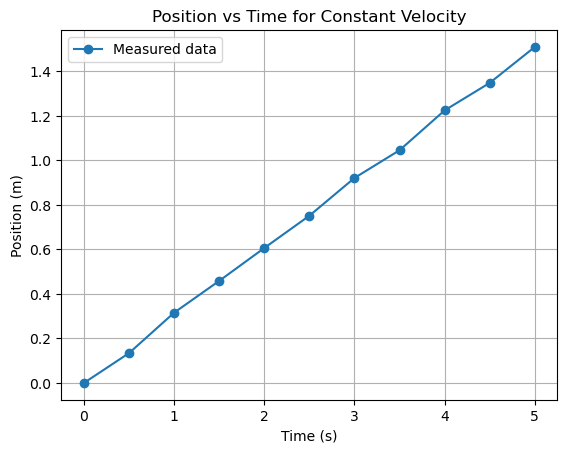

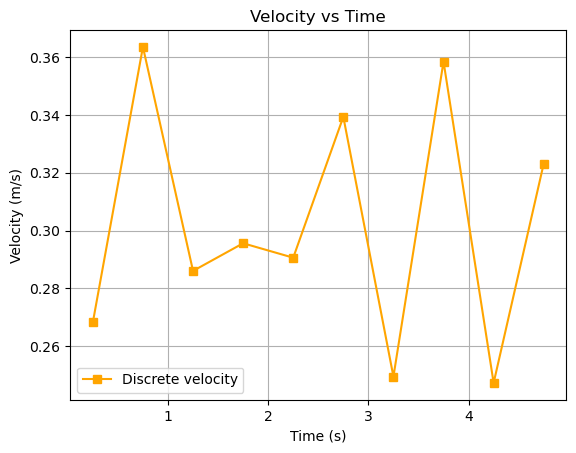

Average velocity ≈ 0.302 m/s


In [28]:
# Sample Completed Solution

%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Given data
t = np.arange(0, 5.5, 0.5)
x = 0.3 * t + 0.02 * np.random.randn(len(t))  # nearly constant velocity, small noise

# Step 2: Plot x(t)
plt.figure()
plt.plot(t, x, 'o-', label='Measured data')
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs Time for Constant Velocity")
plt.grid(True)
plt.legend()
plt.show()

# Step 3: Compute discrete velocity
v = np.diff(x) / np.diff(t)

# Step 4: Midpoints of time
t_mid = 0.5 * (t[1:] + t[:-1])

# Step 5: Plot velocity vs time
plt.figure()
plt.plot(t_mid, v, 's-', color='orange', label='Discrete velocity')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs Time")
plt.grid(True)
plt.legend()
plt.show()

# Step 6: Report mean velocity
v_mean = np.mean(v)
print(f"Average velocity ≈ {v_mean:.3f} m/s")


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.6 — Constant Acceleration Motion

A small object is released from rest and accelerates uniformly along a straight track. You will **generate the data yourself** and then analyze it.

**Physical setup**
- The object starts from rest: $v_0 = 0$.
- Constant acceleration: $a = 2.0\ \text{m/s}^2$.
- Simulation duration: $t_{\text{max}} = 5.0\ \text{s}$.
- Use a time step of $\Delta t = 0.1\ \text{s}$.
- Add small random noise (e.g., $\pm 0.02\ \text{m}$) to the position data to simulate measurement uncertainty.

**Tasks**
1. Generate time and position data using
   
   $$
   x(t) = x_0 + v_0 t + \tfrac{1}{2} a t^2
   $$
   
   with added noise.  
2. Plot **position** vs **time** and verify that it looks roughly quadratic.  
3. Compute discrete **velocity** from the noisy data using finite differences.  
4. Plot **velocity** vs **time**.  

**Hint:**  
Use `np.random.normal(0, noise_amplitude, size=t.size)` to add small noise to position data.


In [8]:
# Pseudocode 

# 1) Import numpy and matplotlib.pyplot
# 2) Define constants:
#       a_true = 2.0
#       v0 = 0
#       x0 = 0
#       dt = 0.1
#       t_max = 5.0
# 3) Create time array t = np.arange(0, t_max + dt, dt)
# 4) Compute ideal (noise-free) position: x_clean = 0.5 * a_true * t**2
# 5) Add random noise to position:
#       rng = np.random.default_rng()
#       x = x_clean + rng.normal(0, 0.02, size=t.size)
# 6) Plot x vs t (markers + line)
# 7) Compute discrete velocity: v = np.gradient(x, t)
# 8) Plot v vs t.

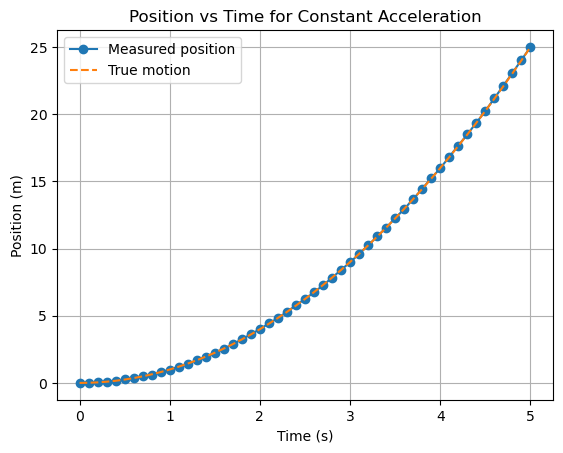

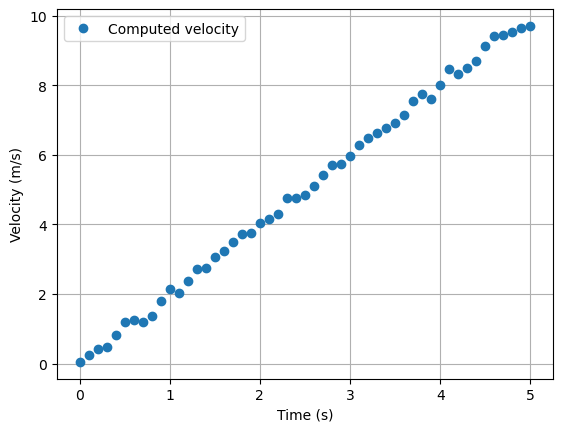

In [7]:
# Sample Solution 
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Constants
a_true = 2.0      # m/s^2
v0 = 0.0
x0 = 0.0
dt = 0.1
t_max = 5.0

# Step 2: Time array
t = np.arange(0, t_max + dt, dt)

# Step 3: Ideal and noisy position
x_clean = x0 + v0*t + 0.5*a_true*t**2
rng = np.random.default_rng(0)
x = x_clean + rng.normal(0, 0.02, size=t.size)  # add ±0.02 m noise

# Step 4: Plot position vs time
plt.figure()
plt.plot(t, x, 'o-', label='Measured position')
plt.plot(t, x_clean, '--', label='True motion')
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs Time for Constant Acceleration")
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Compute discrete velocity
v = np.gradient(x, t)

# Step 6: Plot velocity with fit
plt.figure()
plt.plot(t, v, 'o', label='Computed velocity')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.7 — Kinematics of an Accelerated Particle Beam

Physicists at a particle accelerator are testing a new injector that accelerates charged particles along a straight beamline.  
The acceleration is expected to be **constant** while the injector is active.

A detector records the **position** of the beam front at different times as the particles accelerate through the chamber.  
However, the measurements contain small random fluctuations due to timing and sensor noise.

You will analyze the data to verify that the motion is consistent with **constant acceleration**.

---

### **Physical model**

If the beam starts from rest at $x = 0$, its motion is described by

$$
x(t) = \tfrac{1}{2} a t^2,
$$

where $a$ is the acceleration of the beam front.

If we plot $x$ vs $t^2$, the data should lie on a straight line:

$$
x = m\,t^2 + b,
$$

where the slope $m = \tfrac{1}{2}a$ and ideally $b \approx 0$.

---

### **Your tasks**

1. Generate 12–15 time values between 0 s and 4 s.  
2. Assume the **true acceleration** of the beam front is $a = 6.0\ \text{m/s}^2$.  
3. Compute the *ideal* positions from  
   $$
   x_{\text{ideal}} = \tfrac{1}{2} a t^2
   $$
   and then add small Gaussian (normal) noise (standard deviation ≈ 0.2 m) to simulate measurement uncertainty.  
4. Perform a **linear regression** of $x$ vs $t^2$ to find the best-fit line.  
5. Report the slope $m$, intercept $b$, the **coefficient of determination** $R^2$, and the **correlation coefficient** $r$.  
6. Compute the fitted acceleration from $a_{\text{fit}} = 2m$ and compare it to the true value.  
7. Create a **scatter plot** of $x$ vs $t^2$ with the fitted line overlaid, and annotate the plot with $a_{\text{fit}}$, $R^2$, and $r$.

---

### **Questions to consider**

- Does the data support the assumption of constant acceleration?  
- What does the value of $R^2$ tell you about the consistency of the measurements?  
- If $r$ is close to 1 but $b$ is not near zero, what might that mean about your data?


In [ ]:
# Pseudocode

# 1) Import numpy and matplotlib
# 2) Define constants:
#       a_true = 6.0  # m/s²
# 3) Generate time values: t = np.linspace(0, 4, 15)
# 4) Compute ideal positions: x_ideal = 0.5 * a_true * t**2
# 5) Add random noise to x: rng.normal(0, 0.2, size=t.size)
# 6) Prepare variable for fitting: t2 = t**2
# 7) Fit x vs t² using np.polyfit(t2, x, 1)
# 8) Compute fitted line: x_fit = m*t2 + b
# 9) Compute:
#       - R² = 1 - SS_res/SS_tot
#       - correlation coefficient r = np.corrcoef(t2, x)[0,1]
# 10) Compute fitted acceleration: a_fit = 2*m
# 11) Plot data (x vs t²) and best-fit line, annotate with a_fit, R², r.


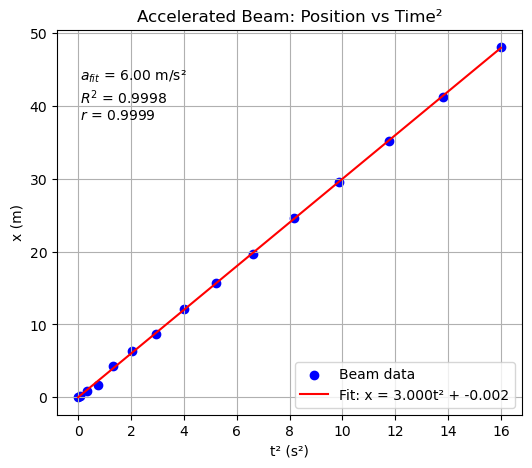

True acceleration: 6.000 m/s²
Fitted acceleration: 6.000 m/s²
Intercept b = -0.002 m
R² = 0.9998
Correlation coefficient r = 0.9999
Percent error = 0.01%


In [29]:
# Sample solution

%reset -f

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Constants
a_true = 6.0  # m/s²
rng = np.random.default_rng(2)

# Step 2: Generate data
t = np.linspace(0, 4, 15)                # seconds
x_ideal = 0.5 * a_true * t**2            # m
x = x_ideal + rng.normal(0, 0.2, size=t.size)  # noisy measurement

# Step 3: Prepare variable for linear fit
t2 = t**2

# Step 4: Linear regression
m, b = np.polyfit(t2, x, 1)
x_fit = m * t2 + b

# Step 5: Compute R² and correlation coefficient
ss_res = np.sum((x - x_fit)**2)
ss_tot = np.sum((x - np.mean(x))**2)
R2 = 1 - ss_res / ss_tot
r = np.corrcoef(t2, x)[0, 1]

# Step 6: Compute fitted acceleration
a_fit = 2 * m

# Step 7: Plot
plt.figure(figsize=(6,5))
plt.scatter(t2, x, label='Beam data', color='blue')
plt.plot(t2, x_fit, color='red', label=f'Fit: x = {m:.3f}t² + {b:.3f}')
plt.xlabel('t² (s²)')
plt.ylabel('x (m)')
plt.title('Accelerated Beam: Position vs Time²')
plt.legend()
plt.grid(True)
plt.text(0.05, 0.90,
         f"$a_{{fit}}$ = {a_fit:.2f} m/s²\n$R^2$ = {R2:.4f}\n$r$ = {r:.4f}",
         transform=plt.gca().transAxes, va='top')
plt.show()

# Step 8: Print summary
print(f"True acceleration: {a_true:.3f} m/s²")
print(f"Fitted acceleration: {a_fit:.3f} m/s²")
print(f"Intercept b = {b:.3f} m")
print(f"R² = {R2:.4f}")
print(f"Correlation coefficient r = {r:.4f}")
print(f"Percent error = {(a_fit - a_true)/a_true * 100:.2f}%")


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.8 — Cart on a Shallow Incline (constant acceleration)

A low-friction cart rolls down a **5°** incline from rest. You recorded position along the incline, $x(t)$, at uniform time steps $\Delta t = 0.10\ \text{s}$. Because of measurement noise, the data are not perfectly quadratic.

**Tasks**
1. Plot $x$ vs $t$ with point markers and a light line by generating some data with random noise.  
2. Estimate the **instantaneous velocity** using a discrete derivative (finite differences or `np.gradient`) and plot $v$ vs $t$.  
3. Fit a **straight line** to $v(t)$ to estimate the **acceleration** $a$ and report the slope and the coefficient of determination $R^2$.  
4. Overlay the best-fit line on the $v(t)$ plot and annotate the plot with the fitted $a$ (units: m/s$^2$).

**Kinematics reminders**

For constant acceleration motion starting from rest:

$$
x(t) \approx \tfrac{1}{2} a\, t^2, 
\qquad
v(t) \approx a\, t.
$$

Discrete derivative (uniform $\Delta t$): 

$$
v_i \approx \frac{x_{i+1}-x_{i-1}}{2\,\Delta t}
\quad (\text{central difference}).
$$

Use SI units throughout.


In [10]:
# Pseudocode

# 1) Create time array t with dt = 0.10 s (e.g., 0 to ~3 s)
# 2) Generate x(t) data ~ (1/2)*a*t^2 with small random noise
# 3) Plot x vs t (markers + line)
# 4) Compute velocity v = np.gradient(x, t)
# 5) Fit v ≈ a*t + b using np.polyfit(t, v, 1)
# 6) Compute R^2 = 1 - SS_res/SS_tot
# 7) Plot v vs t with fit line; annotate plot with fitted a and R^2


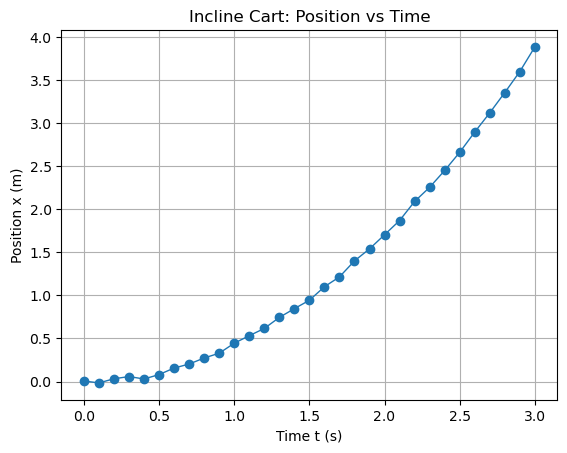

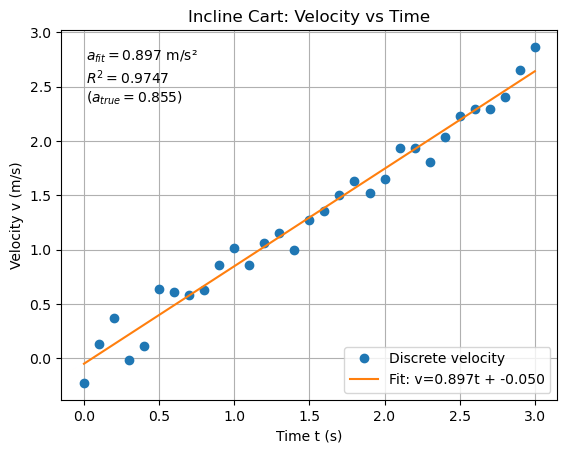

Estimated acceleration â = 0.8968 m/s²
True acceleration a_true = 0.8550 m/s²
R² = 0.9747


In [32]:
# Sample solution

%reset -f

import numpy as np
import matplotlib.pyplot as plt

dt = 0.10
t = np.arange(0, 3.1, dt)

# Theoretical acceleration along incline
g = 9.81
theta = np.deg2rad(5.0)
a_true = g*np.sin(theta)

# Generate position data with small random noise
x_clean = 0.5*a_true*t**2
rng = np.random.default_rng(42)
x = x_clean + rng.normal(0.00, 0.02, size=t.size)

# Plot x(t)
plt.figure()
plt.plot(t, x, 'o-', linewidth=1)
plt.xlabel("Time t (s)")
plt.ylabel("Position x (m)")
plt.title("Incline Cart: Position vs Time")
plt.grid(True)
plt.show()

# Compute velocity
v = np.gradient(x, t)

# Fit v = a*t + b
a_hat, b_hat = np.polyfit(t, v, 1)
v_fit = a_hat*t + b_hat

# R^2
ss_res = np.sum((v - v_fit)**2)
ss_tot = np.sum((v - np.mean(v))**2)
R2 = 1 - ss_res/ss_tot

# Plot v(t)
plt.figure()
plt.plot(t, v, 'o', label='Discrete velocity')
plt.plot(t, v_fit, '-', label=f'Fit: v={a_hat:.3f}t + {b_hat:.3f}')
plt.xlabel("Time t (s)")
plt.ylabel("Velocity v (m/s)")
plt.title("Incline Cart: Velocity vs Time")
plt.legend()
plt.grid(True)
plt.text(0.05, 0.95, f"$a_{{fit}} = {a_hat:.3f}$ m/s²\n$R^2 = {R2:.4f}$\n$(a_{{true}} = {a_true:.3f})$",
         transform=plt.gca().transAxes, va='top')
plt.show()

print(f"Estimated acceleration â = {a_hat:.4f} m/s²")
print(f"True acceleration a_true = {a_true:.4f} m/s²")
print(f"R² = {R2:.4f}")

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.9 — Vertical Toss from Video Tracking

A small steel ball is tossed vertically upward and tracked with video analysis, yielding discrete height data $y(t)$ at uniform $\Delta t = 0.05\ \text{s}$. Air drag is small.

**Tasks**
1. Plot $y$ vs $t$ (markers + smooth fit).  
2. Fit the quadratic model
   
   $$
   y(t) = y_0 + v_0 t - \tfrac{1}{2} g t^2
   $$
   
   to estimate $y_0$, $v_0$, and $g$.  
3. From the fitted quadratic, compute an **analytic velocity**
   
   $$
   v_{\text{fit}}(t) = v_0 - g t.
   $$
   
4. Compute a **discrete** velocity using numerical differentiation of $y(t)$.  
5. Plot both velocities on the same axes and discuss differences (noise vs. model).

**Physics notes**

Ideal vertical toss (no drag):

$$
a(t) = -g, \quad v(t) = v_0 - g t, \quad y(t) = y_0 + v_0 t - \tfrac{1}{2} g t^2.
$$

The peak height occurs when $v=0$, i.e., $t_\text{peak} = v_0/g$.


In [ ]:
# Pseudocode

# 1) Create t array with dt = 0.05 s
# 2) Generate y(t) ~ y0 + v0*t - 0.5*g*t^2 with small noise
# 3) Fit quadratic y = a2*t^2 + a1*t + a0
# 4) Map: g_hat = -2*a2, v0_hat = a1, y0_hat = a0
# 5) Compute analytic v_fit = 2*a2*t + a1
# 6) Compute discrete v_disc = np.gradient(y, t)
# 7) Plot y(t) with fit and v(t) comparison


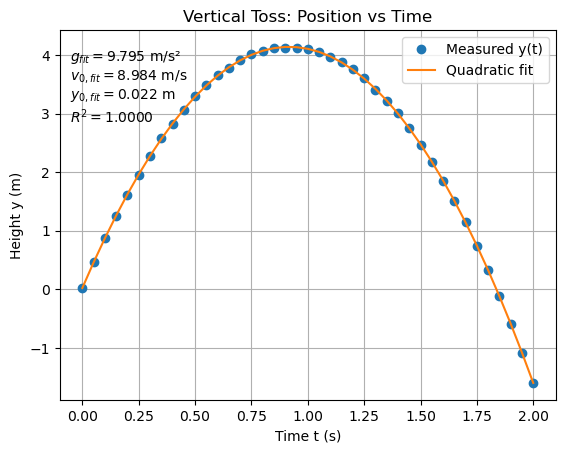

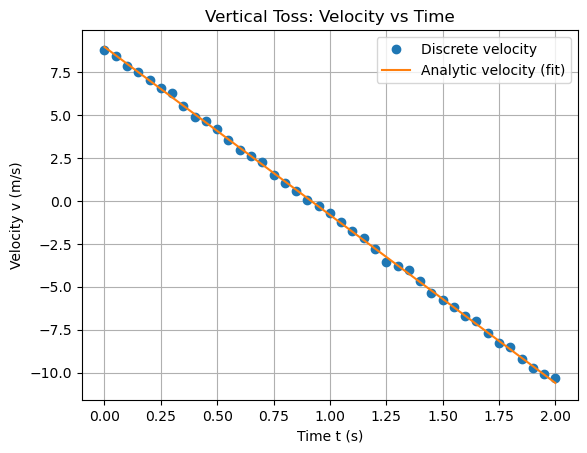

ĝ = 9.795 (true 9.810)
v₀̂ = 8.984 (true 9.000)
y₀̂ = 0.022 (true 0.020)
R² = 1.0000


In [33]:
# Sample solution

%reset -f 

import numpy as np
import matplotlib.pyplot as plt

dt = 0.05
t = np.arange(0, 2.05, dt)

g_true = 9.81
y0_true = 0.02
v0_true = 9.0
y_clean = y0_true + v0_true*t - 0.5*g_true*t**2
rng = np.random.default_rng(7)
y = y_clean + rng.normal(0.0, 0.01, size=t.size)

# Fit quadratic y = a2*t^2 + a1*t + a0
a2, a1, a0 = np.polyfit(t, y, 2)
y_fit = a2*t**2 + a1*t + a0

g_hat = -2*a2
v0_hat = a1
y0_hat = a0

# R^2
ss_res = np.sum((y - y_fit)**2)
ss_tot = np.sum((y - np.mean(y))**2)
R2 = 1 - ss_res/ss_tot

# Plot y(t)
plt.figure()
plt.plot(t, y, 'o', label='Measured y(t)')
plt.plot(t, y_fit, '-', label='Quadratic fit')
plt.xlabel("Time t (s)")
plt.ylabel("Height y (m)")
plt.title("Vertical Toss: Position vs Time")
plt.legend()
plt.grid(True)
plt.text(0.02, 0.95,
         f"$g_{{fit}} = {g_hat:.3f}$ m/s²\n$v_{{0,fit}} = {v0_hat:.3f}$ m/s\n$y_{{0,fit}} = {y0_hat:.3f}$ m\n$R^2 = {R2:.4f}$",
         transform=plt.gca().transAxes, va='top')
plt.show()

# Compute velocities
v_fit = 2*a2*t + a1
v_disc = np.gradient(y, t)

plt.figure()
plt.plot(t, v_disc, 'o', label='Discrete velocity')
plt.plot(t, v_fit, '-', label='Analytic velocity (fit)')
plt.xlabel("Time t (s)")
plt.ylabel("Velocity v (m/s)")
plt.title("Vertical Toss: Velocity vs Time")
plt.legend()
plt.grid(True)
plt.show()

print(f"ĝ = {g_hat:.3f} (true {g_true:.3f})")
print(f"v₀̂ = {v0_hat:.3f} (true {v0_true:.3f})")
print(f"y₀̂ = {y0_hat:.3f} (true {y0_true:.3f})")
print(f"R² = {R2:.4f}")


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.10

In an experiment studying the mass of a muon from 1000 particle collisions, a set of measurements was taken. The mass of the muon, in units of MeV/c$^2$, follows a normal distribution with a mean value around 105.66 MeV/c$^2$ and a standard deviation of approximately 0.02 MeV/c$^2$.

Use the script below to generate the data and 

1. Confirm the mean of the full dataset of 1000 measurements.
2. Confirm the standard deviation of the dataset.
3. Calculate the 95% confidence interval for the true mean mass of the muon based on the 1000 measurements.

In [36]:
%reset -f
import numpy as np

# Parameters for muon mass distribution
mean_mass = 105.66  # Mean mass of the muon in MeV/c^2
std_dev_mass = 0.02  # Standard deviation of the mass in MeV/c^2
num_measurements = 1000  # Number of measurements to generate

# Generate 1000 random muon mass measurements based on a normal distribution
muon_mass_data = np.random.normal(loc=mean_mass, scale=std_dev_mass, size=num_measurements)

# Save the data to a file (optional)
# np.savetxt('muon_mass_data.txt', muon_mass_data)

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.11

In an experiment, the position of an object in free fall is recorded at regular time intervals. Ignorant above the nature of the experiment, we attempt to fit the data to a straight line using **least squares method**. 

Using the script below to generate the data, then

1. Fit a straight line and find the Best-Fit Line.
2. Calculate the goodness of the fit.

In [38]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Parameters for the parabolic equation
a = -9.8  # Acceleration due to gravity in m/s^2
b = 0    # Initial velocity in m/s
c = 1000    # Initial position in m
num_points = 5000  # Number of data points

# Time values from 0 to 10 seconds
t = np.linspace(0, 10, num_points)

# Generate the parabolic data points
y_actual = 0.5*a * t**2 + b * t + c

# Add some noise to simulate experimental error
noise = np.random.normal(0, 100, size=num_points)

y_noisy = y_actual + noise

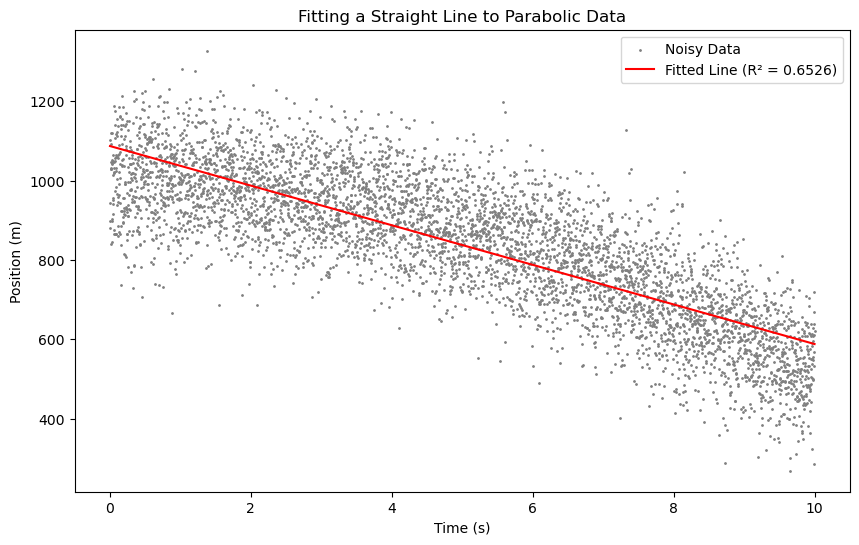

Slope of fitted line: -49.92 m/s
Intercept of fitted line: 1087.40 m
R-squared value: 0.6526


In [37]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Parameters for the parabolic equation
a = -9.8  # Acceleration due to gravity in m/s^2
b = 0    # Initial velocity in m/s
c = 1000    # Initial position in m
num_points = 5000  # Number of data points

# Time values from 0 to 10 seconds
t = np.linspace(0, 10, num_points)

# Generate the parabolic data points
y_actual = 0.5*a * t**2 + b * t + c

# Add some noise to simulate experimental error
noise = np.random.normal(0, 100, size=num_points)

y_noisy = y_actual + noise

# Fit a straight line to the noisy data using least squares method
slope, intercept, r_value, p_value, std_err = linregress(t, y_noisy)

# Calculate R-squared (coefficient of determination)
r_squared = r_value**2

# Plot the original parabolic data, the noisy data, and the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(t, y_noisy, color='gray', s=1, label="Noisy Data")
#plt.plot(t, a * t**2 + b * t + c, color='blue', label="Actual Parabolic Data")
plt.plot(t, slope * t + intercept, color='red', label=f"Fitted Line (R² = {r_squared:.4f})")
plt.title("Fitting a Straight Line to Parabolic Data")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.show()

# Print results
print(f"Slope of fitted line: {slope:.2f} m/s")
print(f"Intercept of fitted line: {intercept:.2f} m")
print(f"R-squared value: {r_squared:.4f}")


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Problem B2.12

In an experiment, the position of an object in free fall is recorded at regular time intervals. Ignorant above the nature of the experiment, we attempt to fit the data to a straight line using **least squares method**. 

Using the script below to generate the data, then

1. Fit a straight line and find the Best-Fit Line.
2. Calculate the goodness of the fit.
3. Calculate the correlation coefficient.

In [39]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define the true parameters of the straight-line equation
m = -2.5  # Slope (constant acceleration)
b = 50    # Initial velocity (intercept)
num_points = 5000  # Number of data points

# Generate time values from 0 to 10 seconds (spaced evenly)
t = np.linspace(0, 10, num_points)

# Generate the true velocity values
v_true = m * t + b

# Add some random noise to simulate measurement errors
noise = np.random.normal(0, 2, size=num_points)  # Small Gaussian noise with std deviation 2
v_noisy = v_true + noise

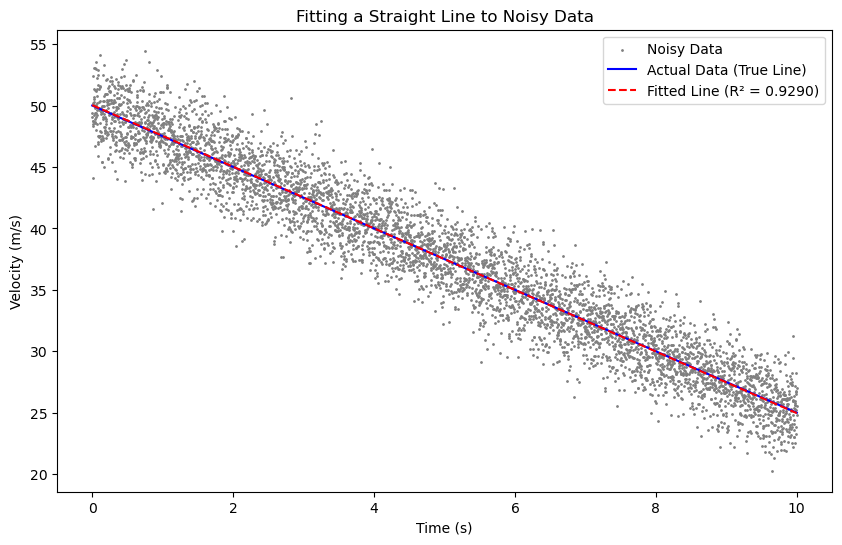

True slope: -2.50, Fitted slope: -2.51
True intercept: 50.00, Fitted intercept: 50.04
R-squared value: 0.9290
Correlation coefficient: -0.9638


In [40]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Define the true parameters of the straight-line equation
m = -2.5  # Slope (constant acceleration)
b = 50    # Initial velocity (intercept)
num_points = 5000  # Number of data points

# Generate time values from 0 to 10 seconds (spaced evenly)
t = np.linspace(0, 10, num_points)

# Generate the true velocity values
v_true = m * t + b

# Add some random noise to simulate measurement errors
noise = np.random.normal(0, 2, size=num_points)  # Small Gaussian noise with std deviation 2
v_noisy = v_true + noise

# Fit a straight line using least squares regression
slope, intercept, r_value, p_value, std_err = linregress(t, v_noisy)

# Calculate R-squared (coefficient of determination)
r_squared = r_value**2

# Plot the actual vs noisy data and the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(t, v_noisy, color='gray', s=1, label="Noisy Data")
plt.plot(t, v_true, color='blue', label="Actual Data (True Line)")
plt.plot(t, slope * t + intercept, color='red', linestyle="--", label=f"Fitted Line (R² = {r_squared:.4f})")
plt.title("Fitting a Straight Line to Noisy Data")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.show()

# Print results
print(f"True slope: {m:.2f}, Fitted slope: {slope:.2f}")
print(f"True intercept: {b:.2f}, Fitted intercept: {intercept:.2f}")
print(f"R-squared value: {r_squared:.4f}")
print(f"Correlation coefficient: {r_value:.4f}")

<hr style="height:2px;border-width:0;color:gray;background-color:gray">